# XAIKitTest Object Workflow

This notebook shows the high-level workflow object for an XAI experiment. The `XAIKitTest` object stores the repeated setup once, then delegates to the existing dataset, model, XAI, experiment-design, and simulation interfaces.

## Workflow Outline

1. Setup imports and create the workflow object
2. Define the experimental design
3. Prepare the dataset
4. Generate participant trial rows
5. Train and evaluate the AI model
6. Generate and visualize explanations
7. Configure the cognitive model
8. Run and save simulated experiment results


## 0. Setup

Import notebook dependencies and create one workflow object. The object will hold experiment design, dataset split, model state, generated trials, explanations, and simulation outputs.

In [1]:
# Step 0: import notebook tools and the high-level workflow class.
from pathlib import Path
import sys

import numpy as np
import pandas as pd

# Support launching the notebook from the repo root, tutorials/, or a nested tutorial folder.
repo_root = next(
    candidate
    for candidate in [Path.cwd(), *Path.cwd().parents]
    if (candidate / "src" / "api.py").exists()
)
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from src.api import XAIKitTest
from src.xai_adapter import (
    ExplanationRunConfig,
    combine_explanation_tables,
    generate_xai_explanation_tables,
    init_explanation_run,
)

# Create one workflow/session object for this experiment.
xaikitTest = XAIKitTest(
    project_name="wine_quality_object_demo",  # Human-readable name for this workflow run.
    output_dir=".",  # Base folder for generated trial, explanation, and result artifacts.
)


## 1. Configure Experimental Design

Define manipulated variables, controlled variables, and dependent variables once on the workflow object.

### 1.1 Add IVs, CVs, and DVs

Independent variables are experimental manipulations. Control variables and dependent variables become columns or outputs in generated experiment data.

In [2]:
# Step 1: build the experimental design on the workflow object.
# `add_iv` delegates validation to src.experiment_design and stores the result on `xaikitTest.iv_config`.
xaikitTest.add_iv(
    "xai_method",  # IV name used later to choose explanation methods.
    "between",  # Between-subjects: each participant sees one XAI method condition.
    ["shap", "lime", "lrp"],  # Experimental levels; `none` is the no-XAI control condition.
)

xaikitTest.add_iv(
    "tested_w_xai",  # IV name indicating whether a trial includes an explanation.
    "within",  # Within-subjects: each participant can see multiple levels.
    [True, False],  # Trial-level condition values.
    randomization="trial",  # Randomize and balance this IV at the trial level.
)

# Add controlled variables; these are stored as trial metadata.
xaikitTest.add_cv("age_group", ["young", "adult", "senior"])
xaikitTest.add_cv("gender", ["male", "female"])

# Add dependent variables; the simulation step emits values for these names.
xaikitTest.add_dv("accuracy", ["continuous"])
xaikitTest.add_dv("task_time", ["continuous"])

# Validate and print a compact design summary.
xaikitTest.validate_design(show=True)



IV configuration:
  xai_method           type=between  randomization=-     levels=['shap', 'lime', 'lrp']
  tested_w_xai         type=within   randomization=trial levels=[True, False]

CVs: ['age_group', 'gender']
DVs: ['accuracy', 'task_time']


({'xai_method': {'type': 'between', 'levels': ['shap', 'lime', 'lrp']},
  'tested_w_xai': {'type': 'within',
   'levels': [True, False],
   'randomization': 'trial'}},
 {'age_group': ['young', 'adult', 'senior'], 'gender': ['male', 'female']},
 {'accuracy': ['continuous'], 'task_time': ['continuous']})

## 2. Prepare Dataset

Load the dataset through the repository dataloader, optionally select/rank features, and create a stable train/test split.

In [3]:
# Step 2: load and split the dataset.
# Feature order is ranked by absolute correlation with the target before training and XAI generation.

# Optional feature-selection example.
# Uncomment this block to rank only these candidate wine-quality columns, then keep 5 features.
# xaikitTest.prepare_dataset(
#     "wine_quality",  # Dataset id listed by src.data_loaders.
#     feature_cols=["Alcohol", "Sulphates", "SO2", "Vinegar Taint", "citric acid"],  # Candidate feature names.
#     num_features=5,  # Keep the first 5 after target-correlation ranking.
#     rank_features_by_target=True,  # Rank candidates before slicing/training.
#     test_size=0.2,  # Hold out 20% of rows for testing and trial sampling.
#     random_state=42,  # Reproducible split.
# )

data = xaikitTest.prepare_dataset(
    "wine_quality",  # Dataset id to load.
    rank_features_by_target=True,  # Rank all features by target correlation.
    test_size=0.2,  # Fraction of rows reserved for test/trial sampling.
    random_state=123,  # Reproducible train/test split.
)


Available training datasets: ['adult', 'breast_cancer', 'cardiotocography', 'forest_cover', 'heart_disease', 'king_county_housing', 'mushrooms', 'prima_diabetes', 'wine_quality']
Dataset   : wine_quality  (1599 rows, 11 model features)
Features  : ['Alcohol', 'Vinegar Taint', 'citric acid', 'Sulphates', 'density', 'SO2', 'fixed acidity', 'chlorides', 'free sulfur dioxide', 'pH', 'residual sugar']
Train set : 1279 samples  (80%)
Test set  : 320 samples  (20%)
Class balance (train) -> class 0: 1105
Class balance (train) -> class 1: 174
First test instanceIds: [1347, 152, 1447, 1254, 847, 1562, 316, 1048, 429, 1432]


## 3. Generate Experimental Trials

Use the stored design and dataset to generate participant assignments, trial rows, and export files.

In [4]:
# Step 3: generate trial rows from the stored design and prepared dataset.
trial_result = xaikitTest.generate_trials(
    model_name="mlp",  # Model label written into controlled trial metadata.
    participants_per_between_condition=25,  # Participant count for each between-subjects condition cell.
    trials_per_participant=10,  # Number of trial rows generated per participant.
    trial_randomization_strategy="balanced",  # Balance trial-randomized IV levels per participant.
    output_dir="experiment_output",  # Folder for trials.csv, trials.json, and design_summary.json.
    seed=42,  # Reproducible participant assignment and instance sampling.
    preview_rows=10,  # Print a compact preview of the first trial rows.
)

# The object keeps these artifacts for later steps.
trials = xaikitTest.trials
experiment_structure = xaikitTest.trial_result.experiment_structure


Counterbalancing strategy: complete_counterbalancing
Participant assignments: 75 total
Instance pool rows: 320
Trial rows: 750
Exported trial artifacts:
  CSV     : experiment_output/trials.csv
  JSON    : experiment_output/trials.json
  Summary : experiment_output/design_summary.json

Previewing first 10 trial rows:
{'participantId': 1, 'trialId': 1, 'block': 1, 'trialWithinBlock': 1, 'withinCondition': 'single_condition', 'xai_method': 'shap', 'tested_w_xai': False, 'dataId': 'wine_quality', 'instanceId': '1049'}
{'participantId': 1, 'trialId': 2, 'block': 1, 'trialWithinBlock': 2, 'withinCondition': 'single_condition', 'xai_method': 'shap', 'tested_w_xai': True, 'dataId': 'wine_quality', 'instanceId': '911'}
{'participantId': 1, 'trialId': 3, 'block': 1, 'trialWithinBlock': 3, 'withinCondition': 'single_condition', 'xai_method': 'shap', 'tested_w_xai': True, 'dataId': 'wine_quality', 'instanceId': '353'}
{'participantId': 1, 'trialId': 4, 'block': 1, 'trialWithinBlock': 4, 'withinCo

## 4. Train AI Model

Create and train the model through the AI model interface. The object stores the model wrapper and raw engine for prediction and explanation generation.

,target_accuracy,final_accuracy,epochs,batch_size,reached_target,model_type,dataset
0,0.9,0.903831,200,1000,True,mlp,wine_quality


,epochs,accuracy,target_accuracy,reached_target
0,10,0.863956,0.9,False
1,20,0.863956,0.9,False
2,30,0.863956,0.9,False
3,40,0.868647,0.9,False
4,50,0.880375,0.9,False
5,60,0.885848,0.9,False
6,70,0.883503,0.9,False
7,80,0.893667,0.9,False
8,90,0.891321,0.9,False
9,100,0.889758,0.9,False


<Axes: title={'center': 'Training Accuracy Checkpoints'}, xlabel='Epochs', ylabel='Accuracy'>

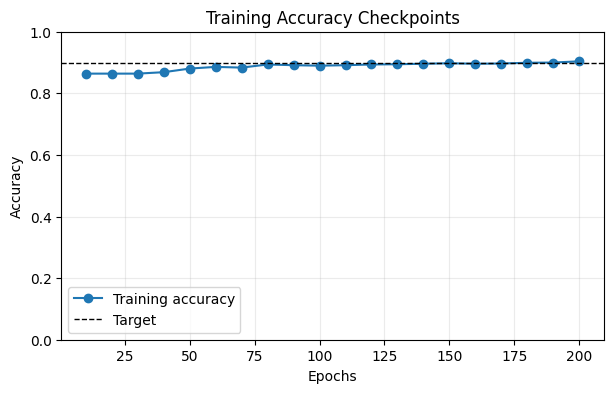

In [5]:
# Step 4: train the AI model used by later prediction and XAI steps.
# Training is quiet by default; set verbose=True if you want raw epoch-by-epoch logs.
model = xaikitTest.train_AI_model(
    model_type="mlp",  # Model family created by src.ai_models.ModelManager.
    target_accuracy=0.90,  # Stop when training accuracy reaches this value, if possible.
    max_epochs=300,  # Hard cap so training cannot run forever.
    check_every_epochs=10,  # Train in chunks, then evaluate the stopping condition.
    batch_size=1000,  # Rows per optimization batch.
    verbose=False,  # Suppress long epoch logs for a cleaner notebook review.
)

# Compact training review tables.
training_summary = xaikitTest.training_summary_table()
training_history = xaikitTest.training_history_table()

display(training_summary)
display(training_history)

# Plot checkpoint accuracy against the target stopping threshold.
xaikitTest.plot_training_history()


## 5. Evaluate AI Model

Report classic data-science metrics through the AI model interface layer.

,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,average_precision,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
train,0.903831,0.736131,0.704000,0.505747,0.588629,0.931045,0.708867,0.814738,0.736131,0.76709,0.895346,0.903831,0.896994
test,0.881250,0.676014,0.586207,0.395349,0.472222,0.855344,0.514653,0.748430,0.676014,0.70266,0.867055,0.881250,0.871168


<Axes: title={'center': 'ROC-AUC Curves'}, xlabel='False Positive Rate', ylabel='True Positive Rate'>

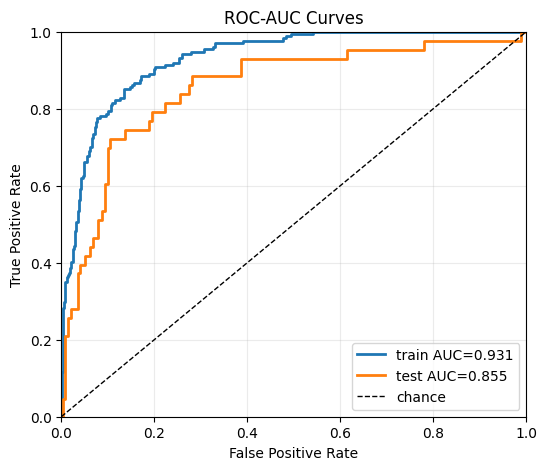

In [6]:
# Step 5: evaluate train and test splits with accuracy, F1, AUC, precision, recall, and confusion matrix.
metrics = xaikitTest.evaluate(
    split="both",  # Evaluate both train and test splits.
    positive_label=1,  # Positive class for binary metrics such as F1 and AUC.
    threshold=0.5,  # Threshold used if predictions are returned as one-dimensional probabilities.
)

# Show scalar metrics as a compact table instead of a nested dictionary.
metrics_table = xaikitTest.metrics_table()
display(metrics_table)

# Plot train/test ROC curves with AUC in the legend.
xaikitTest.plot_auc_curves(split="both", positive_label=1)


## 6. Generate Explanations

Generate one table per XAI method and combine them into the format used by the experimental trial/simulation workflow.

### 6.1 Build Explanation Tables

The method list can be supplied directly here, or inferred from the `xai_method` IV stored in the design.

In [7]:
# Step 6.1: generate explanation tables for selected XAI methods.
combined_path, combined_df = xaikitTest.explanations(
    methods=["shap", "lime", "lrp"],  # Methods to generate; `none` is skipped as the control condition.
    model_name="mlp",  # Model label used in generated CSV filenames.
    output_dir="generated_explanation",  # Folder for method-level and combined explanation CSVs.
    target=1,  # Target class explained by class-specific attribution methods.
    method_kwargs={
        "shap": {"n_background_samples": 30},  # Small background sample for tutorial speed.
        "shap_kernel": {"n_background_samples": 30},  # Kernel SHAP background control if used.
        "lime": {"num_samples": 1000},  # LIME perturbation samples.
    },
)

print(f"Combined explanation path: {combined_path}")
combined_df.head() if combined_df is not None else None



Generating explanations for xai method: shap


/Users/wangzhuoyulucas/anaconda3/envs/xaik-api-dev/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
100%|██████████| 320/320 [00:13<00:00, 24.25it/s]


  Saved: generated_explanation/shap_mlp_wine_quality.csv shape=(320, 18)

Generating explanations for xai method: lime
  Saved: generated_explanation/lime_mlp_wine_quality.csv shape=(320, 18)

Generating explanations for xai method: lrp
  Saved: generated_explanation/lrp_mlp_wine_quality.csv shape=(320, 18)

Combined explanation CSV: generated_explanation/de_mlp_wine_quality.csv shape=(960, 18)
Combined explanation path: generated_explanation/de_mlp_wine_quality.csv


,dataId,modelName,expMethod,instanceId,pred,i_max,a0_i,a1_i,a2_i,a3_i,a4_i,a5_i,a6_i,a7_i,a8_i,a9_i,a10_i,intercept
0,wine_quality,mlp,shap,1347,0,0.067183,-0.684385,-0.311164,0.095682,-1.000000,0.041586,0.225051,-0.117688,0.025705,0.000000,-0.065718,-0.194812,0.135876
1,wine_quality,mlp,shap,152,0,0.032696,-0.902864,-0.486797,-0.022566,-1.000000,0.116169,-0.876874,-0.220252,-0.196826,0.000000,-0.172353,-0.304688,0.135876
2,wine_quality,mlp,shap,1447,0,0.067408,-1.000000,-0.374139,0.143960,0.415370,-0.055790,-0.036264,-0.202465,0.019260,0.000000,-0.148942,-0.270807,0.135876
3,wine_quality,mlp,shap,1254,0,0.041704,0.066192,-1.000000,0.144416,0.173889,0.000000,0.094573,-0.164534,0.085064,0.052765,-0.305872,-0.732014,0.135876
4,wine_quality,mlp,shap,847,0,0.049675,-1.000000,-0.540996,0.071670,0.166676,-0.137853,-0.031177,-0.181085,0.000000,0.048210,-0.437922,-0.390731,0.135876


### 6.2 Visualize One Explanation

Use the XAI adapter visualization helper through the workflow object. Influence is the signed attribution view; importance keeps support for the predicted class.

/Users/wangzhuoyulucas/Documents/GitHub/xaikit-test-api/src/xai_adapter/visualization.py:171: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  shown = pd.concat([
/Users/wangzhuoyulucas/Documents/GitHub/xaikit-test-api/src/xai_adapter/visualization.py:171: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  shown = pd.concat([


(<Figure size 1050x490 with 5 Axes>,
 array([<Axes: title={'center': 'Attribute'}>,
        <Axes: title={'center': 'Value'}>, <Axes: >,
        <Axes: title={'center': 'Importance'}>, <Axes: >], dtype=object))

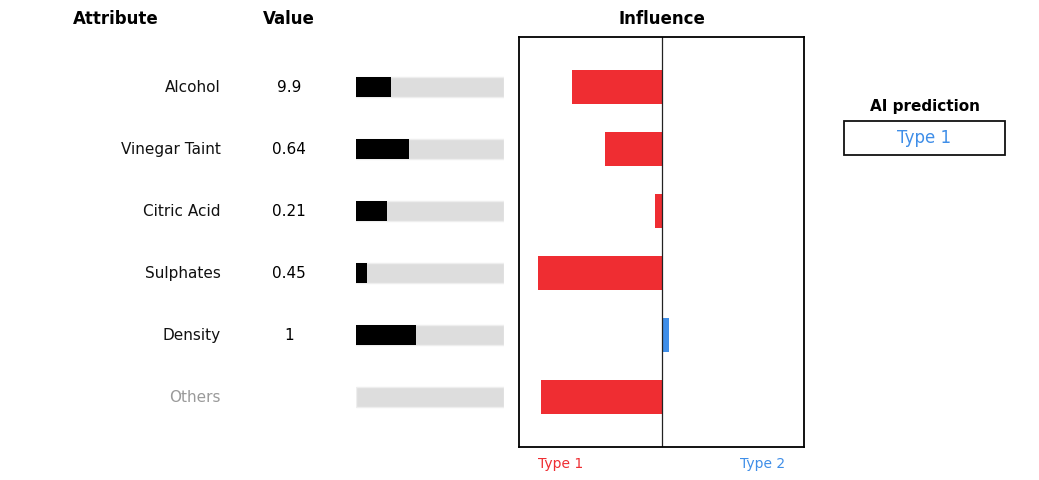

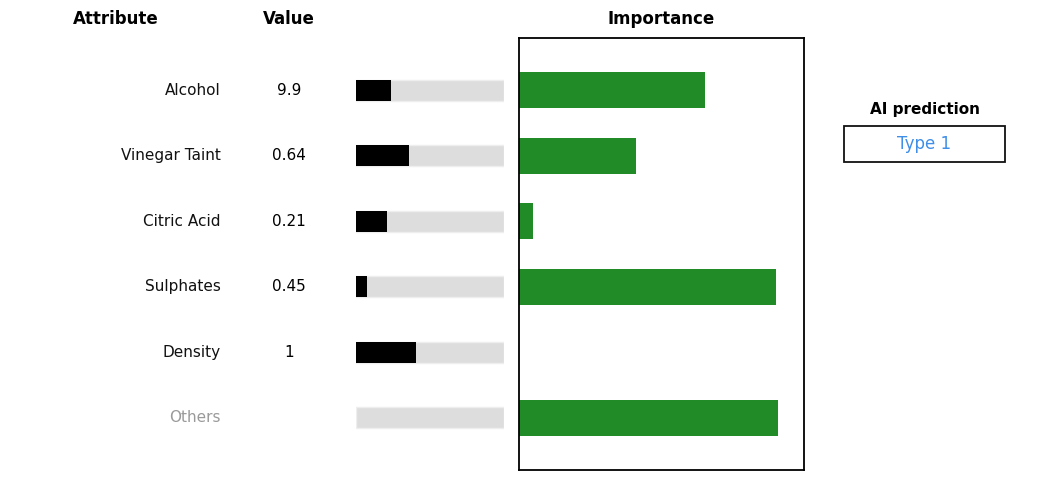

In [8]:
# Step 6.2: visualize a local explanation for one test instance.
xaikitTest.plot_explanation(
    visualization="influence",  # Signed red/blue attribution view.
    method="shap",  # Explanation method to visualize.
    instance_id=int(xaikitTest.data.test_instance_ids[200]),  # Test instance to plot.
    top_n=5,  # Show the first 5 predefined/ranked features plus an Others row.
    class_labels=["Type 1", "Type 2"],  # Labels shown in the prediction panel.
)

xaikitTest.plot_explanation(
    visualization="importance",  # Signed red/blue attribution view.
    method="shap",  # Explanation method to visualize.
    instance_id=int(xaikitTest.data.test_instance_ids[200]),  # Test instance to plot.
    top_n=5,  # Show the first 5 predefined/ranked features plus an Others row.
    class_labels=["Type 1", "Type 2"],  # Labels shown in the prediction panel.
)


## 7. Configure Cognitive Model

Store the cognitive-model callable and parameters once. The default is a deterministic tutorial placeholder.

In [9]:
# Step 7: configure cognitive-model settings for simulation.
# With no callable passed, this uses the default deterministic placeholder from src.cognitive_models.
xaikitTest.set_cognitive_model(
    cognitive_params=None,  # None loads default cognitive parameter values.
)

xaikitTest.cognitive_params


{'cog_retrieval_threshold': -0.3,
 'cog_latency_factor': 0.2,
 'cog_T_enc': 1.5,
 'cog_T_op': 0.5,
 'cog_ddm_a': 0.8,
 'cog_ddm_s': 1.0,
 'cog_chi': 0.001,
 'lapse': 0.005}

## 8. Run Experiment Simulation

Run the cognitive model over generated trial rows, then save simulated outputs for downstream analysis.

### 8.1 Run a Participant Preview

Start with one participant so the output shape is easy to inspect.

In [10]:
# Step 8.1: run a one-participant simulation preview.
simulated_results = xaikitTest.run_experiment(
    mode="participant_by_participant",  # Select all trials for one participant.
    participant_id=1,  # Participant id to preview.
)

simulated_results.head(10)

,participantId,trialId,block,trialWithinBlock,withinCondition,tested_w_xai,xai_method,dataId,instanceId,model_type,...,cog_param_cog_ddm_s,cog_param_cog_chi,cog_param_lapse,accuracy,task_time,prob_correct,pred_time,agent_prediction,ai_prediction,cognitive_correct_vs_ai
0,1,1,1,1,single_condition,False,shap,wine_quality,1049,mlp,...,1.0,0.001,0.005,0.620788,3.355754,0.620788,3.355754,True,0,False
1,1,2,1,2,single_condition,True,shap,wine_quality,911,mlp,...,1.0,0.001,0.005,0.630210,3.544204,0.630210,3.544204,True,0,False
2,1,3,1,3,single_condition,True,shap,wine_quality,353,mlp,...,1.0,0.001,0.005,0.620672,3.353446,0.620672,3.353446,True,1,True
3,1,4,1,4,single_condition,False,shap,wine_quality,688,mlp,...,1.0,0.001,0.005,0.620855,3.357105,0.620855,3.357105,True,0,False
4,1,5,1,5,single_condition,False,shap,wine_quality,1226,mlp,...,1.0,0.001,0.005,0.621078,3.361551,0.621078,3.361551,True,0,False
5,1,6,1,6,single_condition,False,shap,wine_quality,487,mlp,...,1.0,0.001,0.005,0.618363,3.307268,0.618363,3.307268,True,0,False
6,1,7,1,7,single_condition,False,shap,wine_quality,1022,mlp,...,1.0,0.001,0.005,0.617903,3.298059,0.617903,3.298059,True,0,False
7,1,8,1,8,single_condition,True,shap,wine_quality,1199,mlp,...,1.0,0.001,0.005,0.619897,3.337931,0.619897,3.337931,True,0,False
8,1,9,1,9,single_condition,True,shap,wine_quality,858,mlp,...,1.0,0.001,0.005,0.619454,3.329083,0.619454,3.329083,True,0,False
9,1,10,1,10,single_condition,True,shap,wine_quality,1188,mlp,...,1.0,0.001,0.005,0.617703,3.294062,0.617703,3.294062,True,0,False


### 8.2 Save Results

Persist the simulated trial-level outputs as CSV and JSON.

In [11]:
# Step 8.2: save the most recent simulation result.
sim_csv_path, sim_json_path = xaikitTest.save_results(
    out_dir="experiment_output",  # Output folder for simulated_results.csv/json.
)

print(f"Saved CSV : {sim_csv_path}")
print(f"Saved JSON: {sim_json_path}")


Saved CSV : experiment_output/simulated_results.csv
Saved JSON: experiment_output/simulated_results.json
